In [ ]:
# ── Install required libraries ──────────────────────────────────────
!pip install -q transformers datasets evaluate torch pandas matplotlib seaborn scikit-learn kagglehub librosa fvcore

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00


In [ ]:
# ── Imports ──────────────────────────────────────────────────────────
import torch
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
import time
from IPython.display import Image, display, Audio

from transformers import (
    ASTFeatureExtractor,   # was AutoFeatureExtractor
    ASTForAudioClassification,  # was AutoModelForAudioClassification
    TrainingArguments,
    Trainer,
    pipeline
)
import evaluate
from datasets import Dataset, DatasetDict, load_from_disk, concatenate_datasets
from sklearn.metrics import confusion_matrix, classification_report

# Print PyTorch and device information
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU             : NVIDIA L4


In [ ]:
# Get access to my Google Drive (for loading the datasets)
from google.colab import drive
drive.mount('/content/drive')

import os
# Check what is actually inside that folder
print(os.listdir('/content/drive/MyDrive/HuBERT/BirdCLEF/'))

Mounted at /content/drive
['spotted_towhee', 'house_wren', 'northern_cardinal', 'common_raven', 'european_starling', 'curve_billed_thrasher', 'song_sparrow', 'red_winged_blackbird', 'red_crossbill', 'barn_swallow']


In [ ]:
# Rebuild the label dictionaries globally
species = sorted([d for d in os.listdir('/content/drive/MyDrive/HuBERT/BirdCLEF/') if os.path.isdir(os.path.join('/content/drive/MyDrive/HuBERT/BirdCLEF/', d))])
labels = species
label2id = {name: i for i, name in enumerate(species)}
id2label = {i: name for i, name in enumerate(species)}
print(f"Unique labels: {labels}")

Unique labels: ['barn_swallow', 'common_raven', 'curve_billed_thrasher', 'european_starling', 'house_wren', 'northern_cardinal', 'red_crossbill', 'red_winged_blackbird', 'song_sparrow', 'spotted_towhee']


In [ ]:
!cp -r /content/drive/MyDrive/HuBERT/BirdCLEF/ /content/BirdCLEF_local/

NameError: name 'target_dir' is not defined

In [ ]:
target_dir ="/content/BirdCLEF_local/"
# Verify the copy worked
if os.path.exists(target_dir):
    contents = os.listdir(target_dir)
    print(f"Local directory created. Found {len(contents)} items.")
    print(f"Samples: {contents[:5]}")
else:
    print("Error: Target directory was not created.")

Local directory created. Found 10 items.
Samples: ['curve_billed_thrasher', 'house_wren', 'song_sparrow', 'spotted_towhee', 'red_crossbill']


In [ ]:
# ── Load AST model & Extractor ───────────────────────────────────────

# Use MIT's AST base model
MODEL_CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"

# Use AutoFeatureExtractor instead of AutoTokenizer (for compatibility with audio, not text)
feature_extractor = ASTFeatureExtractor.from_pretrained(MODEL_CHECKPOINT)
print(f"Feature extractor loaded: {MODEL_CHECKPOINT}")

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

Feature extractor loaded: MIT/ast-finetuned-audioset-10-10-0.4593


In [ ]:
# ── AST Dataset Generator ────────────────────────────────────────────

def ast_audio_generator(data_path, limit_per_class=500):
    for bird in species:
        print(f"Extracting AST spectrograms for: {bird}")
        folder_path = os.path.join(data_path, bird)
        files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.ogg', '.wav', '.mp3', '.m4a'))]

        count = 0
        for f in files:
            if count >= limit_per_class: break
            file_path = os.path.join(folder_path, f)
            try:
                # 1. Load the audio
                audio, _ = librosa.load(file_path, sr=16000)
                # 2. AST PREPROCESSING (Creates 2D Spectrogram Tensors)
                encoded = feature_extractor(
                    audio,
                    sampling_rate=16000,
                    return_tensors="np"
                )
                # 3. Yield to the dataset builder
                yield {
                    "input_values": encoded["input_values"][0],
                    "label": label2id[bird]
                }
                count += 1
            except Exception as e:
                pass # Skip corrupted files silently to keep output clean

# ── RUN THE GENERATOR & SAVE ─────────────────────────────────────────
# WARNING: If you already ran this and saved to Drive, skip building and just load below!
print("Building AST dataset file-by-file...")
ast_dataset = Dataset.from_generator(
    ast_audio_generator,
    gen_kwargs={"data_path": '/content/BirdCLEF_local/'}
)

Building AST dataset file-by-file...


Generating train split: 0 examples [00:00, ? examples/s]

Extracting AST spectrograms for: barn_swallow
Extracting AST spectrograms for: common_raven
Extracting AST spectrograms for: curve_billed_thrasher
Extracting AST spectrograms for: european_starling
Extracting AST spectrograms for: house_wren
Extracting AST spectrograms for: northern_cardinal
Extracting AST spectrograms for: red_crossbill
Extracting AST spectrograms for: red_winged_blackbird
Extracting AST spectrograms for: song_sparrow
Extracting AST spectrograms for: spotted_towhee


In [ ]:
import os
import librosa
import numpy as np
from datasets import Dataset, DatasetDict, concatenate_datasets, Features, Value, ClassLabel

# ── CAST TO CLASSLABEL FOR STRATIFICATION ─────────────────────────
# This tells the dataset that 'label' is a categorical ClassLabel (0-9)
species_names = sorted([d for d in os.listdir('/content/BirdCLEF_local/') if os.path.isdir(os.path.join('/content/BirdCLEF_local/', d))])

# Create the feature schema
class_features = ast_dataset.features.copy()
class_features["label"] = ClassLabel(names=species_names)

# Cast the dataset to the new schema
ast_dataset = ast_dataset.cast(class_features)

# ── SPLIT THE DATASET (70/20/10) ──────────────────────────────────────
print("Splitting BirdCLEF dataset into stratified Train / Validate / Test sets")
first_split = ast_dataset.train_test_split(test_size=0.1, seed=42, stratify_by_column="label") # take 10% for Test
second_split = first_split['train'].train_test_split(test_size=0.222, seed=42, stratify_by_column="label") # 22.2% of 90% left = 20% for Validate

# Build Large dataset (5000 Total, 500 per class)
final_large_datasets = DatasetDict({
    'train': second_split['train'], # 70%
    'validation': second_split['test'], # 20%
    'test': first_split['test'] # 10%
})

def _create_stratified_subset(dataset_dict, train_per_class=105, validate_per_class=30, test_per_class=15, seed=42):
    rng = np.random.default_rng(seed)
    small_dataset = {}
    splits_mapping = {'train': train_per_class, 'validation': validate_per_class, 'test': test_per_class}

    for split_name, per_class in splits_mapping.items():
        print(f"Processing {split_name} subset (Randomized)... ")
        ds = dataset_dict[split_name] # e.g. {[0,3,2,0,1,6,8,4,9...]} (labels for a dataset)
        # Optimization: Use np.where to find indices instead of .filter() which is slow
        labels_array = np.array(ds['label']) # flattens to array
        # Collect #_per_class amount from dataset split
        subsets = []

        for class_id in range(10):
            # Find all indices where label matches class_id
            idx = np.where(labels_array == class_id)[0] # e.g. [0,3,6]
            # Shuffle indices before selecting so training/test sets are diverse
            rng.shuffle(idx)
            selected_idx = idx[:min(per_class, len(idx))] # select up to amount we need or available
            subsets.append(ds.select(selected_idx)) # Add to collection

        small_dataset[split_name] = concatenate_datasets(subsets).shuffle(seed=seed)
    return DatasetDict(small_dataset)

print("Creating the small subset w/ Randomized indexing...")
final_small_datasets = _create_stratified_subset(final_large_datasets)

# Save both datasets to drive permanently
LARGE_SAVE_PATH = '/content/drive/MyDrive/HuBERT_Thai/ast_bird_datasets_large_official'
SMALL_SAVE_PATH = '/content/drive/MyDrive/HuBERT_Thai/ast_bird_datasets_small_official'

final_large_datasets.save_to_disk(LARGE_SAVE_PATH)
final_small_datasets.save_to_disk(SMALL_SAVE_PATH)

print(f"Success! Large AST dataset saved to: {LARGE_SAVE_PATH}")
print(f"Success! Small AST dataset saved to: {SMALL_SAVE_PATH}")

Casting the dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Splitting BirdCLEF dataset into stratified Train / Validate / Test sets
Creating the small subset w/ Randomized indexing...
Processing train subset (Randomized)... 
Processing validation subset (Randomized)... 
Processing test subset (Randomized)... 


Saving the dataset (0/4 shards):   0%|          | 0/3501 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/999 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/1050 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/150 [00:00<?, ? examples/s]

Success! Large AST dataset saved to: /content/drive/MyDrive/HuBERT_Thai/ast_bird_datasets_large_official
Success! Small AST dataset saved to: /content/drive/MyDrive/HuBERT_Thai/ast_bird_datasets_small_official


In [ ]:
LARGE_SAVE_PATH = '/content/drive/MyDrive/HuBERT_Thai/ast_bird_datasets_large_official'
SMALL_SAVE_PATH = '/content/drive/MyDrive/HuBERT_Thai/ast_bird_datasets_small_official'
DATASET_PATH = SMALL_SAVE_PATH
print(os.listdir(DATASET_PATH))

['dataset_dict.json', 'train', 'validation', 'test']


In [ ]:
# ── Load and Subsample Datasets ──────────────────────────────────────

# 1. Load the Master Datasets (the full 500-per-bird set)
def load_datasets(path):
  print(f'Loading AST Datasets from {path}...')
  loaded_datasets = load_from_disk(path)

  train_dataset = loaded_datasets['train']
  val_dataset = loaded_datasets['validation']
  test_dataset = loaded_datasets['test']

  print("Datasets have been loaded.")
  return train_dataset, val_dataset, test_dataset

# ── Metric functions for measuring accuracy ──────────────────────────
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    acc = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")
    prec = precision_metric.compute(predictions=predictions, references=labels, average="macro")
    rec = recall_metric.compute(predictions=predictions, references=labels, average="macro")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": prec["precision"],
        "recall": rec["recall"]
    }

In [ ]:
# ── Load Datasets ─────────────────────────────────────────────────
train_dataset, val_dataset, test_dataset = load_datasets(DATASET_PATH)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

Loading AST Datasets from /content/drive/MyDrive/HuBERT_Thai/ast_bird_datasets_small_official...
Datasets have been loaded.
Train: 1050
Val:   300
Test:  150


In [ ]:
# ── Baseline Evaluation (Untrained Head) ─────────────────────────────
print("\n" + "="*50)
print("Evaluating Base AST (Untrained Classification Head)")
print("="*50)

base_model = ASTForAudioClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=10,
    ignore_mismatched_sizes=True
)

base_trainer = Trainer(
    model=base_model,
    args=TrainingArguments(output_dir="/tmp/base_eval", per_device_eval_batch_size=16, report_to="none"),
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

base_results = base_trainer.predict(test_dataset)
print(f"  Base Accuracy   : {base_results.metrics['test_accuracy']:.4f}")
print(f"  Base F1 Score   : {base_results.metrics['test_f1']:.4f}")


Evaluating Base AST (Untrained Classification Head)


config.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `527`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                          
------------------------+----------+------------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([10])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


  Base Accuracy   : 0.1200
  Base F1 Score   : 0.0445


In [ ]:
# Clean GPU memory (to wipe base model) before fine-tuning
del base_model
del base_trainer
import gc
gc.collect()
torch.cuda.empty_cache()
print("Cleared GPU memory for fine-tuning!")

Cleared GPU memory for fine-tuning!


In [ ]:
# ── Fine-Tuning AST ──────────────────────────────────────────────────
model = ASTForAudioClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=10,
    ignore_mismatched_sizes=True # Required for AST
)

train_epochs=10
lr=2e-5
train_batch_size=8
eval_batch_size=16

# Keep these identical to HuBERT for the research comparison
training_args = TrainingArguments(
    output_dir="/content/ast_training_checkpoints",
    num_train_epochs=train_epochs,
    learning_rate=lr,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=eval_batch_size,
    seed=42,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    save_total_limit=1,
    report_to="none",
)

trainer_birdclef = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `527`.


Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

[transformers] ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                          
------------------------+----------+------------------------------------------------------------------------------------------
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527]) vs model:torch.Size([10])          
classifier.dense.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([527, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
trainer_birdclef.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.689739,0.800000,0.800811,0.818298,0.800000
2,No log,0.602681,0.830000,0.823750,0.844455,0.830000
3,No log,0.649320,0.833333,0.829670,0.849902,0.833333
4,0.368817,0.629978,0.860000,0.860181,0.867431,0.860000
5,0.368817,0.628855,0.873333,0.874249,0.880715,0.873333
6,0.368817,0.646955,0.866667,0.866906,0.872858,0.866667
7,0.368817,0.654566,0.873333,0.873637,0.879755,0.873333
8,0.000619,0.659285,0.873333,0.873507,0.878639,0.873333
9,0.000619,0.661493,0.876667,0.876977,0.881615,0.876667
10,0.000619,0.662593,0.873333,0.873507,0.878639,0.873333


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['audio_spectrogram_transformer.layers.0.attention.q_proj.weight', 'audio_spectrogram_transformer.layers.0.attention.q_proj.bias', 'audio_spectrogram_transformer.layers.0.attention.k_proj.weight', 'audio_spectrogram_transformer.layers.0.attention.k_proj.bias', 'audio_spectrogram_transformer.layers.0.attention.v_proj.weight', 'audio_spectrogram_transformer.layers.0.attention.v_proj.bias', 'audio_spectrogram_transformer.layers.0.attention.o_proj.weight', 'audio_spectrogram_transformer.layers.0.attention.o_proj.bias', 'audio_spectrogram_transformer.layers.0.layernorm_before.weight', 'audio_spectrogram_transformer.layers.0.layernorm_before.bias', 'audio_spectrogram_transformer.layers.0.layernorm_after.weight', 'audio_spectrogram_transformer.layers.0.layernorm_after.bias', 'audio_spectrogram_transformer.layers.0.mlp.fc1.weight', 'audio_spectrogram_transformer.layers.0.mlp.fc1.bias', 'audio_spectrogram_transformer.layers.

TrainOutput(global_step=1320, training_loss=0.13998875640558475, metrics={'train_runtime': 2280.8301, 'train_samples_per_second': 4.604, 'train_steps_per_second': 0.579, 'total_flos': 7.1177061924864e+17, 'train_loss': 0.13998875640558475, 'epoch': 10.0})

In [ ]:
LARGE_MODEL_SAVE_PATH = '/content/drive/MyDrive/HuBERT_Thai/ast_bird_model_large_5000'
SMALL_MODEL_SAVE_PATH = '/content/drive/MyDrive/HuBERT_Thai/ast_bird_model_small_1500'
SAVE_PATH = SMALL_MODEL_SAVE_PATH

In [ ]:
# After training finishes:
print("Saving the BEST model permanently to Google Drive...")
# This only saves the final weights (~300MB), not the 10 epochs of junk
trainer_birdclef.save_model(SAVE_PATH)
print("Done!")

Saving the BEST model permanently to Google Drive...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done!


In [ ]:
# ── Research Analytics & Final Results ───────────────────────────────
num_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {num_params / 1e6:.2f} Million")

if len(trainer_birdclef.state.log_history) > 0:
    train_metrics = trainer_birdclef.state.log_history[-1]
    if 'train_samples_per_second' in train_metrics:
        print(f"Training throughput: {train_metrics['train_samples_per_second']:.2f} samples/sec")

start_inference = time.time()
results = trainer_birdclef.predict(test_dataset)
end_inference = time.time()

total_time = end_inference - start_inference
latency_per_sample = (total_time / len(test_dataset)) * 1000

print("\n" + "=" * 50)
print("AST Fine-Tuned — Final Test Results")
print("=" * 50)
print(f"  Accuracy   : {results.metrics['test_accuracy']:.4f}")
print(f"  F1 Score   : {results.metrics['test_f1']:.4f}")
print(f"  Precision  : {results.metrics['test_precision']:.4f}")
print(f"  Recall     : {results.metrics['test_recall']:.4f}")
print("-" * 50)
print(f"Total Test Inference Time: {total_time:.2f} seconds")
print(f"Average Latency: {latency_per_sample:.2f} ms per bird call")

Total Parameters: 86.20 Million
Training throughput: 4.60 samples/sec



AST Fine-Tuned — Final Test Results
  Accuracy   : 0.8533
  F1 Score   : 0.8547
  Precision  : 0.8605
  Recall     : 0.8533
--------------------------------------------------
Total Test Inference Time: 17.55 seconds
Average Latency: 117.02 ms per bird call


In [ ]:
# ── MACs & FLOPs ───────────────────────────────

from fvcore.nn import FlopCountAnalysis
import torch

# 1. Create a dummy input matching AST's spectrogram shape (1 batch, 1024 time frames, 128 freq bins)
dummy_spectrogram = torch.randn(1, 1024, 128).to(model.device)

# 2. Run the Flop analyzer
print("Calculating AST MACs...")
flops_ast = FlopCountAnalysis(model, dummy_spectrogram)
flops_ast.unsupported_ops_warnings(False)

macs_total = flops_ast.total()
flops_total = macs_total * 2

print("\n" + "="*40)
print(f"AST Computational Complexity")
print("="*40)
print(f"Total MACs (GigaMACs): {macs_total / 1e9:.2f} GMACs")
print(f"Total FLOPs (GigaFLOPs): {flops_total / 1e9:.2f} GFLOPs")
print(f"Total Parameters:      {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")

Calculating AST MACs...

AST Computational Complexity
Total MACs (GigaMACs): 103.47 GMACs
Total FLOPs (GigaFLOPs): 206.93 GFLOPs
Total Parameters:      86.20 M


In [ ]:
# ── SHOW CLASS-LEVEL REPORT ───────────────────────────────────────────────────

y_pred = np.argmax(results.predictions, axis=1)
y_true = results.label_ids
target_names = [id2label[i] for i in range(10)]
print("\n" + "="*60)
print("CLASS-LEVEL PERFORMANCE REPORT (AST)")
print("="*60)
print(classification_report(y_true, y_pred, target_names=target_names))


CLASS-LEVEL PERFORMANCE REPORT (AST)
                       precision    recall  f1-score   support

         barn_swallow       0.93      0.87      0.90        15
         common_raven       1.00      0.93      0.97        15
curve_billed_thrasher       1.00      0.87      0.93        15
    european_starling       0.86      0.80      0.83        15
           house_wren       0.74      0.93      0.82        15
    northern_cardinal       0.94      1.00      0.97        15
        red_crossbill       0.80      0.80      0.80        15
 red_winged_blackbird       0.80      0.80      0.80        15
         song_sparrow       0.69      0.73      0.71        15
       spotted_towhee       0.86      0.80      0.83        15

             accuracy                           0.85       150
            macro avg       0.86      0.85      0.85       150
         weighted avg       0.86      0.85      0.85       150



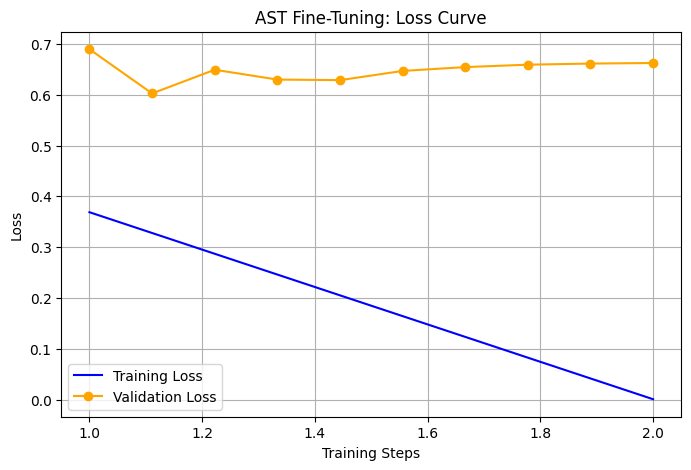

In [ ]:
# ── PLOT LOSS CURVES ────────────────────────────────────────────────────────
# extract the internal logs from trainer object
history = trainer_birdclef.state.log_history

train_loss = [x['loss'] for x in history if 'loss' in x]
val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]

epochs_train = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_train, train_loss, label='Training Loss', color='blue')
if len(val_loss) > 0:
    plt.plot(np.linspace(1, len(train_loss), len(val_loss)), val_loss, label='Validation Loss', color='orange', marker='o')
plt.title('AST Fine-Tuning: Loss Curve')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

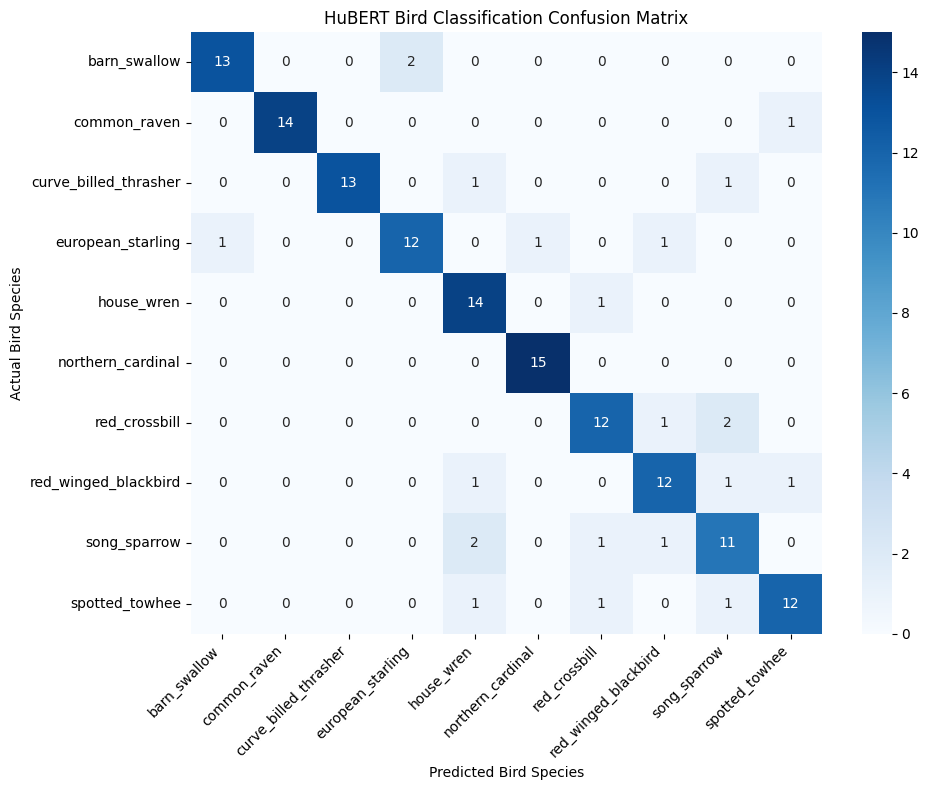

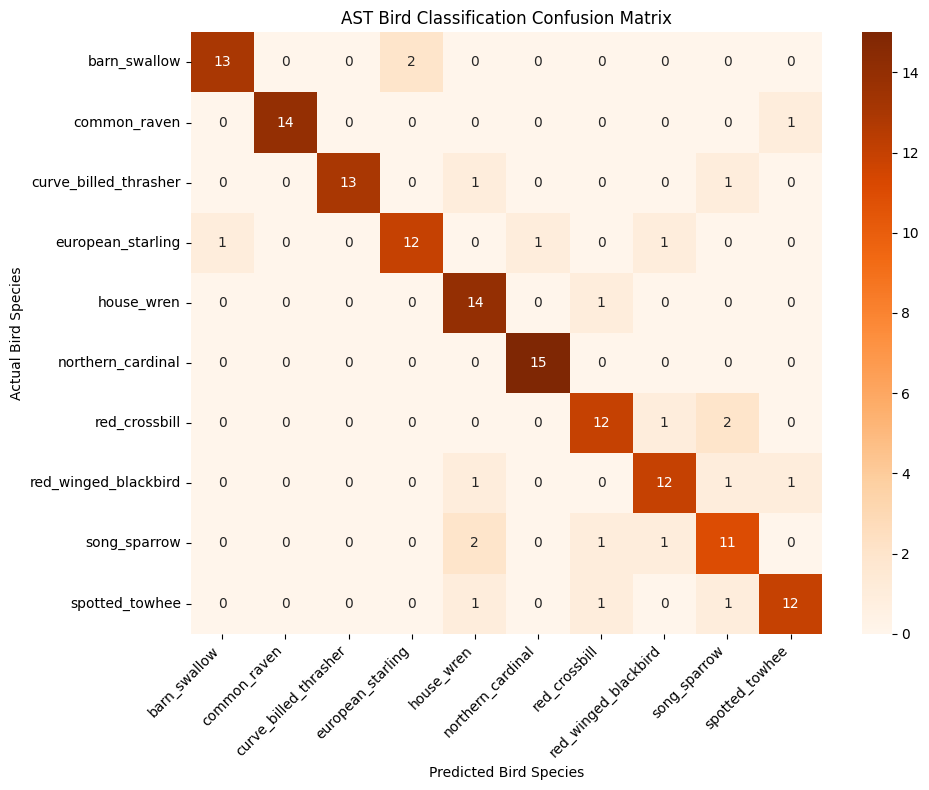

In [ ]:
# ── PLOT CONFUSION MATRIX ───────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix

# Get model's raw predictions on the test dataset
predictions_output = trainer_birdclef.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

# label the axes
unique_labels = sorted(list(set(labels)))

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Seaborn plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('HuBERT Bird Classification Confusion Matrix')
plt.xlabel('Predicted Bird Species')
plt.ylabel('Actual Bird Species')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('AST Bird Classification Confusion Matrix')
plt.xlabel('Predicted Bird Species')
plt.ylabel('Actual Bird Species')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ── Load Saved AST Model ────────────────────────────
# run !pip install block

# run import block

# run Mount Drive and id2label blocks

# run Load Dataset

# Run Plotting Logic

# Run the ast_demo function above

from transformers import pipeline, ASTForAudioClassification, ASTFeatureExtractor

# 1. Point to the saved model on Drive
saved_model_path = SMALL_MODEL_SAVE_PATH # <---- change if need
base_extractor_path = "MIT/ast-finetuned-audioset-10-10-0.4593"

print("Loading saved model from Drive...")
# 2. Load the trained model and the original feature extractor
loaded_model = ASTForAudioClassification.from_pretrained(saved_model_path)
loaded_extractor = ASTFeatureExtractor.from_pretrained(base_extractor_path)

# 3. Rebuild the pipeline for Bert
classification_tool = pipeline(
    "audio-classification",
    model=loaded_model,
    feature_extractor=loaded_extractor,
    device=0 if torch.cuda.is_available() else -1
)

print("AST is online and ready for inference!")

In [ ]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix, classification_report

# Must be installed: !pip install fvcore
from fvcore.nn import FlopCountAnalysis

print("=" * 60)
print("1. AST ARCHITECTURE & COMPLEXITY (LOADED MODEL)")
print("=" * 60)

# A. Calculate Parameters
num_params = sum(p.numel() for p in loaded_model.parameters())
print(f"Total Parameters: {num_params / 1e6:.2f} Million")

# B. Calculate MACs and FLOPs using a Wrapper
class ModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x).logits

wrapped_model = ModelWrapper(loaded_model).eval()
# AST expects a 2D spectrogram input: [Batch, Time_Frames, Freq_Bins]
dummy_spectrogram = torch.randn(1, 1024, 128).to(loaded_model.device)

flops_ast = FlopCountAnalysis(wrapped_model, dummy_spectrogram)
flops_ast.unsupported_ops_warnings(False)
macs_total = flops_ast.total()

print(f"Total MACs:       {macs_total / 1e9:.2f} GMACs")
print(f"Total FLOPs:      {(macs_total * 2) / 1e9:.2f} GFLOPs")


print("\n" + "=" * 60)
print("2. AST INFERENCE & ACCURACY METRICS")
print("=" * 60)

# C. Setup Trainer for Evaluation
ast_eval_trainer = Trainer(
    model=loaded_model,
    args=TrainingArguments(output_dir="/tmp/ast_eval", per_device_eval_batch_size=16, report_to="none"),
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# D. Run Prediction and Time it
start_inference = time.time()
ast_loaded_results = ast_eval_trainer.predict(test_dataset)
end_inference = time.time()

latency_per_sample = ((end_inference - start_inference) / len(test_dataset)) * 1000

print(f"  Accuracy   : {ast_loaded_results.metrics['test_accuracy']:.4f}")
print(f"  F1 Score   : {ast_loaded_results.metrics['test_f1']:.4f}")
print(f"  Precision  : {ast_loaded_results.metrics['test_precision']:.4f}")
print(f"  Recall     : {ast_loaded_results.metrics['test_recall']:.4f}")
print(f"  Latency    : {latency_per_sample:.2f} ms per spectrogram")

# E. Generate Reports and Graphs
y_pred = np.argmax(ast_loaded_results.predictions, axis=1)
y_true = ast_loaded_results.label_ids
unique_labels = sorted(list(set(labels)))
target_names = [id2label[i] for i in range(10)]

print("\n" + "=" * 60)
print("3. CLASS-LEVEL PERFORMANCE REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('AST Classification Confusion Matrix (Loaded Model)')
plt.xlabel('Predicted Bird Species')
plt.ylabel('Actual Bird Species')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ── AST Demo Setup ────────────────────────────

# This function now dynamically looks up the name based on our actual folders
def decode_label(label_str):
    # Hugging Face pipeline returns strings like 'LABEL_0', 'LABEL_1', etc.
    if isinstance(label_str, str) and "LABEL_" in label_str:
        label_id = int(label_str.replace('LABEL_', ''))
        return id2label[label_id]
    return label_str

# Mapping to bird facts (keys must match folder names)
bird_facts = {
    "barn_swallow": "They are the most widespread swallow in the world, but in America,\n they love building mud nests right on human porches.",
    "common_raven": "Ravens are crazy smart—they actually use logic to solve puzzles and\n have been known to sled down snowy roofs just for fun.",
    "curve_billed_thrasher": "The jazz musicians of the desert; they don't just sing, they\n 'thash' their bills through debris to find insects while singing.",
    "european_starling": "Total acoustics experts! They can mimic human speech, car alarms,\n and even the songs of other birds in your dataset.",
    "house_wren": "Don't let the size fool you; these tiny guys are fiercely territorial and\n will aggressively dive-bomb much larger animals.",
    "northern_cardinal": "Unlike most songbirds, both males and females sing. They use their\n loud, clear whistles to communicate like a high-pitched walkie-talkie.",
    "red_crossbill": "Their beaks are literally crossed! This specialized 'tool' lets them\n pry open pine cones that other birds can't touch.",
    "red_winged_blackbird": "The 'bouncers' of the marsh. Their 'Conk-la-ree!' song is so\n loud and distinct it's usually the first thing our model picks up in noisy data.",
    "song_sparrow": "Every male Song Sparrow has a unique, customized song that he uses to\n defend his territory—like a musical fingerprint.",
    "spotted_towhee": "They are the kings of the 'double-scratch'—a hop-and-kick move they\n use to find food in dead leaves, often making more noise than their song!"
}

classification_tool = pipeline(
    "audio-classification",
    model=model,
    feature_extractor=feature_extractor,
    device=0 if torch.cuda.is_available() else -1
)

def ast_demo(file_path):
    # Load and process using the SAME logic as training (10 seconds, 16k sr)
    # This ensures accuracy by matching the input distribution the model was trained on
    audio, _ = librosa.load(file_path, sr=16000, duration=10)

    # Use the classification tool directly
    probabilities = classification_tool(audio)
    result = probabilities[0]
    raw_label = result['label'] # e.g. 'LABEL_0'
    confidence = result['score'] * 100

    raw_bird_name = decode_label(raw_label) # "Common_Raven" or "common raven" (i dont remember)
    search_name = raw_bird_name.lower().replace(" ", "_") # "common_raven" (matches folder/image names)
    bird_name = search_name.replace("_", " ").title() # "Common Raven" (for display)

    fact = bird_facts.get(search_name, "This bird was sponsored as the mascot of Jeffrey Epstein Inc.")

    # --- Output ---
    print(f"[Bert]: Hey Big A\n")
    time.sleep(1.5)
    print(f"[AST]: Yo bert\n")
    time.sleep(1.5)
    print(f"[Bert]: Yo.\n")
    time.sleep(1.0)
    print(f"[Bert]: I can't tell what this bird is can you help a brotha out\n")
    time.sleep(2.0)
    print(f"[AST]: I'm like {confidence:.1f}% sure that's a {bird_name} big dawg.\n")
    print("-" * 40)

    IMAGE_PATH = f'/content/drive/MyDrive/HuBERT/bird_photos/{search_name}.jpg'
      # Display Image
    if os.path.exists(IMAGE_PATH):
      display(Image(filename=IMAGE_PATH, width=400))

    # For AST, we show the input file + show the input & predicted spectrograms
    time.sleep(2.0)
    print(f"\n[AST]: take your audio file back, ion een want that\n")
    display(Audio(audio, rate=16000))
    time.sleep(1.5)
    print(f"\n[AST]: Lemme put you on.\n")

    # 1. Generate the Spectrogram for the input audio
    encoded_input = feature_extractor(audio, sampling_rate=16000, return_tensors="np")
    input_spectrogram = encoded_input["input_values"][0] # 2D array input that AST eats up

    # 2. Find a Reference Spectrogram from our test dataset
    ref_spectrogram = None
    for i in range(len(test_dataset)):
        dataset_bird_name = id2label[test_dataset[i]['label']].lower().replace(" ", "_")
        if dataset_bird_name == search_name:
            ref_spectrogram = np.array(test_dataset[i]['input_values'])
            break

    # 3. Plot them side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Plot 1: The Input
    # We use .T (transpose) and origin='lower' to orient time on the X axis and frequency on the Y axis
    axes[0].imshow(input_spectrogram.T, origin='lower', aspect='auto', cmap='magma')
    axes[0].set_title("What AST Saw (Our Input)")
    axes[0].set_ylabel("Frequency Bins")
    axes[0].set_xlabel("Time Frames")

    # Plot 2: The Reference
    if ref_spectrogram is not None:
        axes[1].imshow(ref_spectrogram.T, origin='lower', aspect='auto', cmap='magma')
        axes[1].set_title(f"Reference: {bird_name} (From Training Data)")
        axes[1].set_xlabel("Time Frames")
    else:
        axes[1].text(0.5, 0.5, 'Reference not found', ha='center', va='center')
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    time.sleep(2.5)
    print(f"\n[AST]: Fun Fact: {fact}\n")
    time.sleep(2.5)
    print(f"[Bert]: U the goat mayn\n")
    time.sleep(2.5)
    print(f"[AST]: Big A out")

[Bert]: Hey Big A

[AST]: Yo bert

[Bert]: Yo.

[Bert]: I can't tell what this bird is can you help a brotha out

[AST]: I'm like 100.0% sure that's a Barn Swallow big dawg.

----------------------------------------


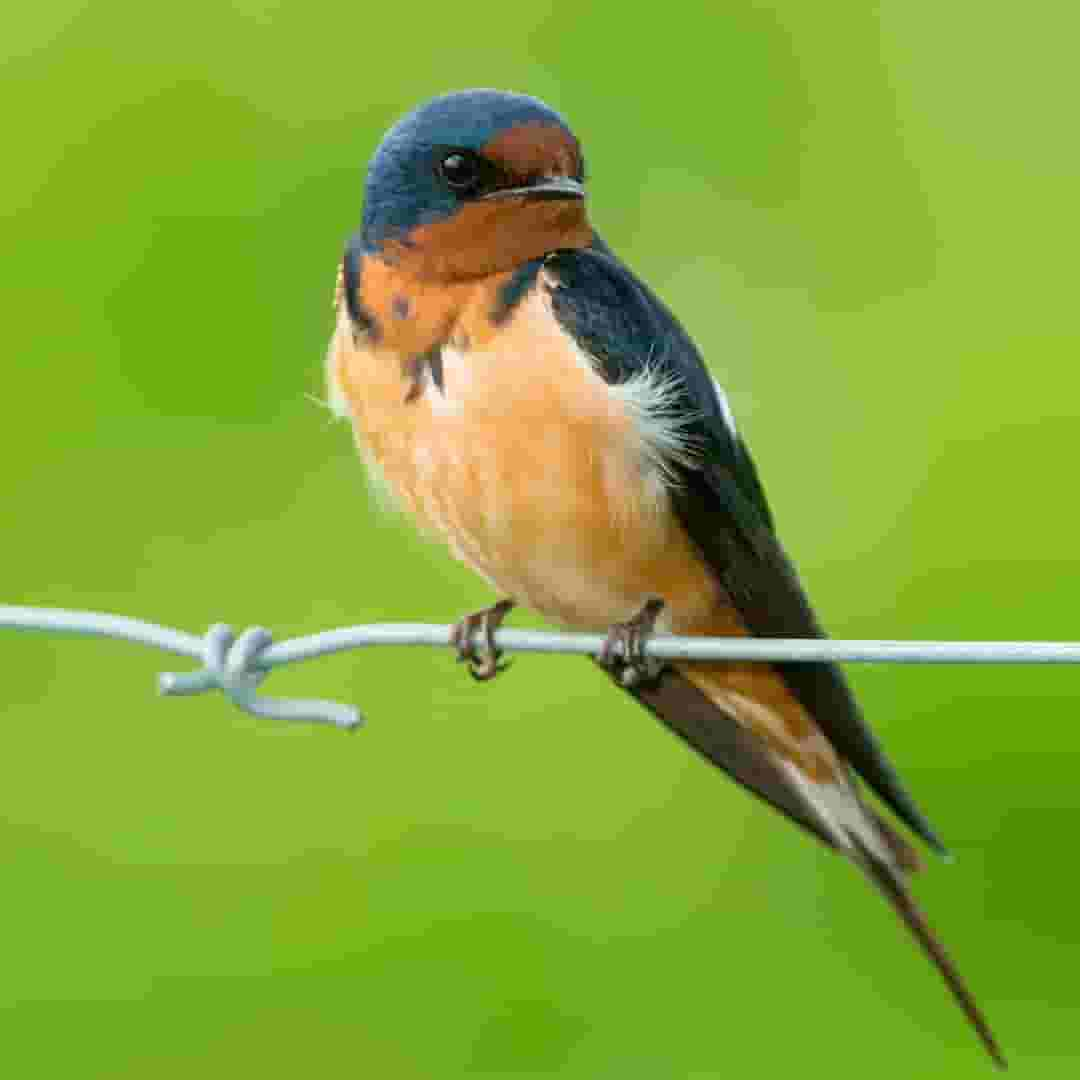


[AST]: take your audio file back, ion een want that




[AST]: Lemme put you on.



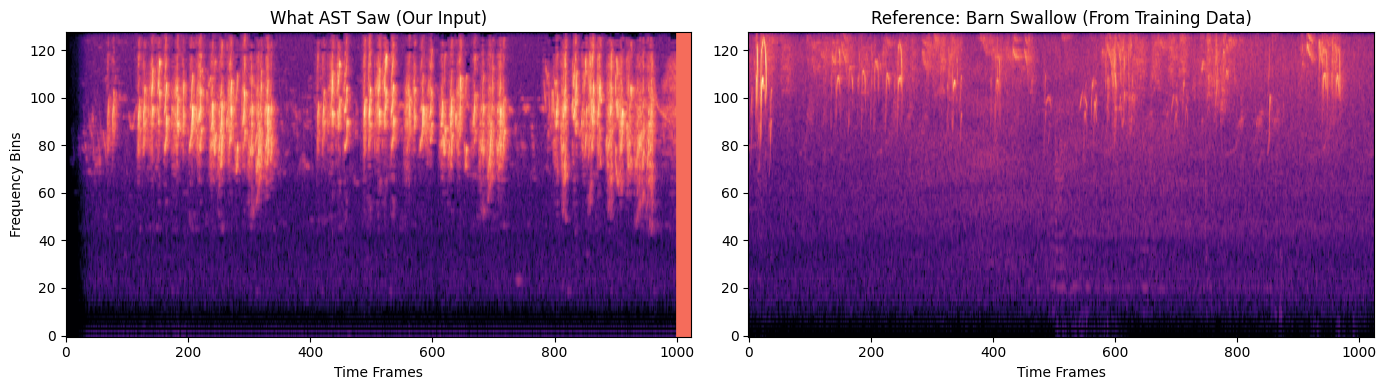


[AST]: Fun Fact: They are the most widespread swallow in the world, but in America,
 they love building mud nests right on human porches.

[Bert]: U the goat mayn

[AST]: Big A out


In [ ]:
# Run Demo
test_file = '/content/drive/MyDrive/HuBERT/test_audio/the-sound-of-swallows.mp3'
ast_demo(test_file)